In [1]:
import json
import pandas as pd
from scraper import AnimeScraper

In [2]:
anime_id = 54492
anime_client = AnimeScraper(anime_id)
# aphotecary_s2_anime_id = 58514

In [3]:
# Get whole info
try:
    with open("data/anime_full_payload_54492.json", "r", encoding="utf-8") as f:
        anime_full_payload = json.loads(f.read())
except FileNotFoundError:
    anime_full_payload = anime_client.get_full_payload()
    # exoprt to file
    with open("data/anime_full_payload_54492.json", "w", encoding="utf-8") as f:
        f.write(json.dumps(anime_full_payload))

try:
    anime_episodes = pd.read_csv("data/anime_episodes_54492.csv")
except FileNotFoundError:
    anime_episodes = anime_client.get_episodes()
    anime_episodes.to_csv("data/anime_episodes_54492.csv", index=False)

try:
    with open("data/anime_user_updates_54492.json", "r", encoding="utf-8") as f:
        anime_user_updates = json.loads(f.read())
except FileNotFoundError:
    anime_user_updates = anime_client.get_user_updates()
    with open("data/anime_user_updates_54492.json", "w", encoding="utf-8") as f:
        f.write(json.dumps(anime_user_updates))

try:
    anime_reviews = pd.read_csv("data/anime_reviews_54492.csv")
    anime_reaction_reviews = pd.read_csv("data/anime_reaction_reviews_54492.csv")
except FileNotFoundError:
    anime_reviews, anime_reaction_reviews, _ = anime_client.get_reviews()
    anime_reviews.to_csv("data/anime_reviews_54492.csv", index=False)
    anime_reaction_reviews.to_csv("data/anime_reaction_reviews_54492.csv", index=False)

Episode scores

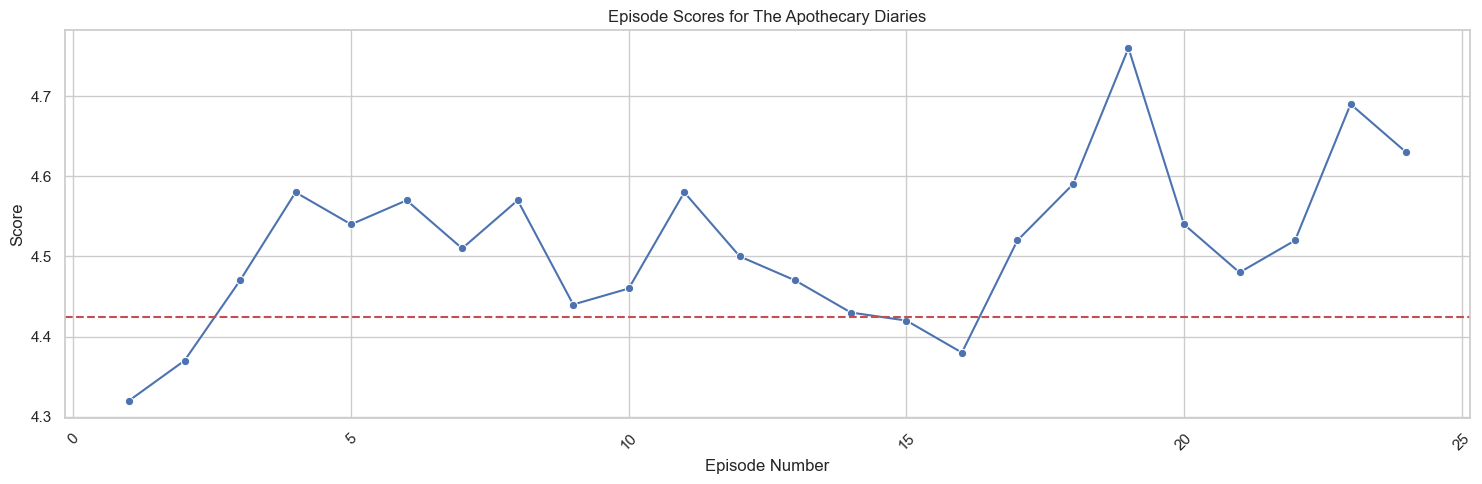

In [5]:
# plot scores per episode
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid")
plt.figure(figsize=(15, 5))
sns.lineplot(data=anime_episodes, x="mal_id", y="score", marker="o")
# add horizontal line for overall anime score
anime_full_payload["data"]["score"] / 2
plt.axhline(xmin = anime_episodes["mal_id"].min() - 1,
            xmax = anime_episodes["mal_id"].max(),
            y = anime_full_payload["data"]["score"] / 2,
            color='r', linestyle='--', label='Overall Score'
        )
plt.title(f"Episode Scores for {anime_full_payload['data']['titles'][-1]['title']}")
plt.xlabel("Episode Number")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Review numbers analysis

In [6]:
anime_reaction_reviews_simple = anime_reaction_reviews.drop(
    columns = ["mal_id", "overall", "anime_id"])

perform clustering over anime_reaction_reviews_simple dataset. for that, use k-means with several cluster values (e.g., from 1 to 7). use a correlation distance metric for the distance matrix. perform evaluation of the created clusters using metrics any way you consider (e.g, using the silhouette coefficients). show the evaluation results for each number of clusters.

In [7]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances, silhouette_score, silhouette_samples

# correlation distance matrix
metric = "correlation"
metric = "euclidean"
corr_dist = pairwise_distances(anime_reaction_reviews_simple, metric = metric)
# we have nans bc all values in some rows are the same.
# let's get  which data points are have all the same column values
if metric == "correlation":
    nan_points = anime_reaction_reviews_simple.index[anime_reaction_reviews_simple.nunique(axis=1) == 1].tolist()
    # let's go for each pair, if both are in nan_points, set value to 1, else 0
    for i in nan_points:
        for j in nan_points:
            if i != j: # don't fill the diagonal, else will throw error
                corr_dist[i][j] = 1.0
    # fill the rest of nans with 0
    corr_dist = np.nan_to_num(corr_dist, nan=0.0)

results = []
sil_samples_list = []
labels_list = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters = k, random_state = 0)
    labels = kmeans.fit_predict(anime_reaction_reviews_simple)
    labels_list.append(labels)

    sil = silhouette_score(corr_dist, labels, metric = "precomputed")
    sil_samples_list.append(silhouette_samples(corr_dist, labels, metric = "precomputed"))
    results.append({"k": k, "silhouette_corr": sil})

results_df = pd.DataFrame(results)
display(results_df)

,k,silhouette_corr
0,2,0.954226
1,3,0.897359
2,4,0.892684
3,5,0.901165
4,6,0.902739
5,7,0.890975
6,8,0.887798
7,9,0.719055


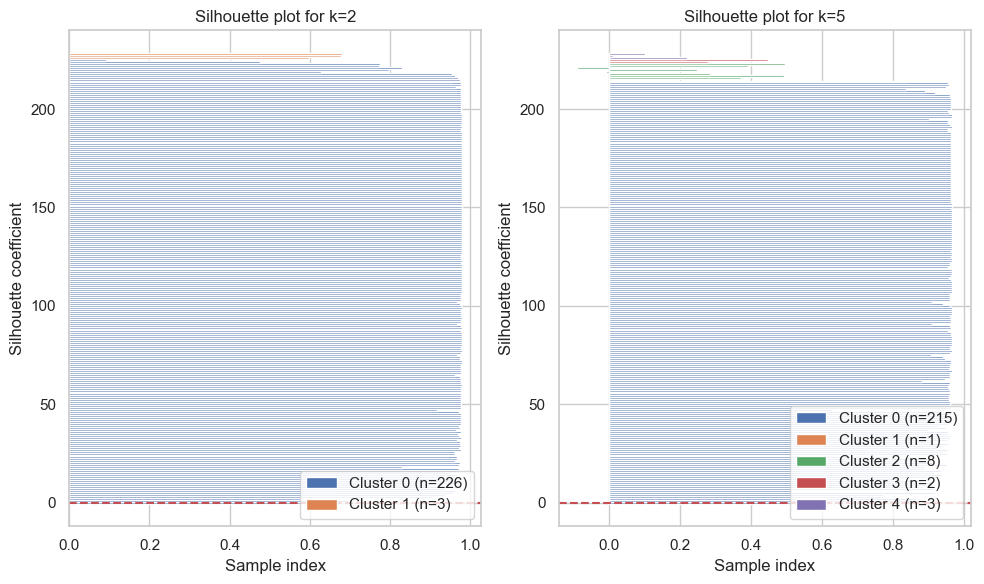

In [8]:
# please graph the silhouette scores for each sample, i want to divide it by label
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
n_plot = 1
for idx, sil_samples in enumerate(sil_samples_list):
    k = idx + 2
    if k not in [2, 5]:
        continue
    plt.subplot(1, 2, n_plot)
    n_plot += 1
    plt.title(f'Silhouette plot for k={k}')
    plt.xlabel('Sample index')
    plt.ylabel('Silhouette coefficient')
    plt.axhline(y=0, color='r', linestyle='--')
    
    # Sort by cluster label for better visualization
    sorted_indices = np.argsort(labels_list[idx])
    sorted_labels = labels_list[idx][sorted_indices]
    sorted_sil_samples = sil_samples[sorted_indices]
    
    # Plot with different colors for each cluster
    y_lower = 0
    for cluster_label in range(k):

        # Get silhouette values for this cluster
        cluster_sil_values = sorted_sil_samples[sorted_labels == cluster_label]
        cluster_size = cluster_sil_values.shape[0]
        
        y_upper = y_lower + cluster_size
        
        plt.barh(range(y_lower, y_upper), cluster_sil_values, height=1.0, 
                 label=f'Cluster {cluster_label} (n={cluster_size})')

        y_lower = y_upper
    plt.legend(loc='lower right')
    plt.tight_layout()
plt.show()

In [9]:
from dimensionality_reduction.pca_model import PCAModel
pca_model = PCAModel(anime_reaction_reviews_simple)
pca_model.fit(n_components = 7, preprocessing = "none")

# from sklearn.decomposition import PCA
# pca = PCA(n_components = 7) # we have more arguments!!!

First 6 components have eigenvalues > 1


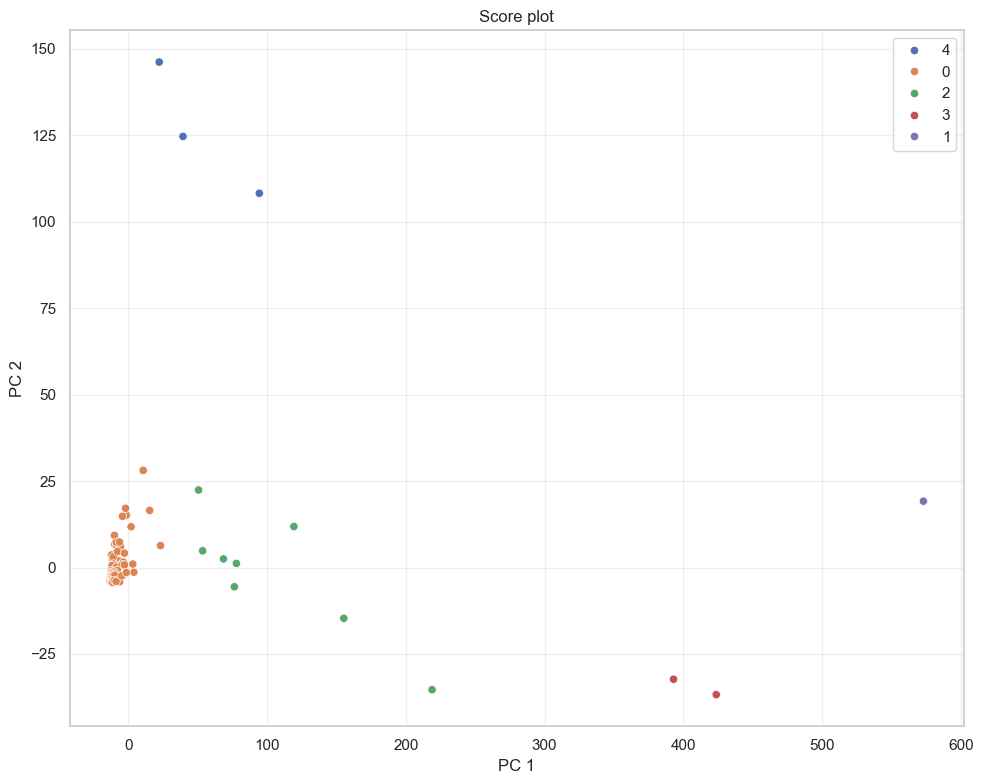

In [10]:
pca_model.kaiser_components()
k = 5
labels = list(map(str,labels_list[k - 2]))

fig = pca_model.plot_scores(score_color = labels)
plt.show()

In [11]:
anime_reaction_reviews_pca[anime_reaction_reviews_pca["PC_0"] > 500]
aa = anime_reaction_reviews.iloc[anime_reaction_reviews_pca[anime_reaction_reviews_pca["PC_0"] > 500].index].merge(anime_reviews, on = "mal_id")
print(aa["review"][0])

NameError: name 'anime_reaction_reviews_pca' is not defined

Selected components (above expected variance): 1


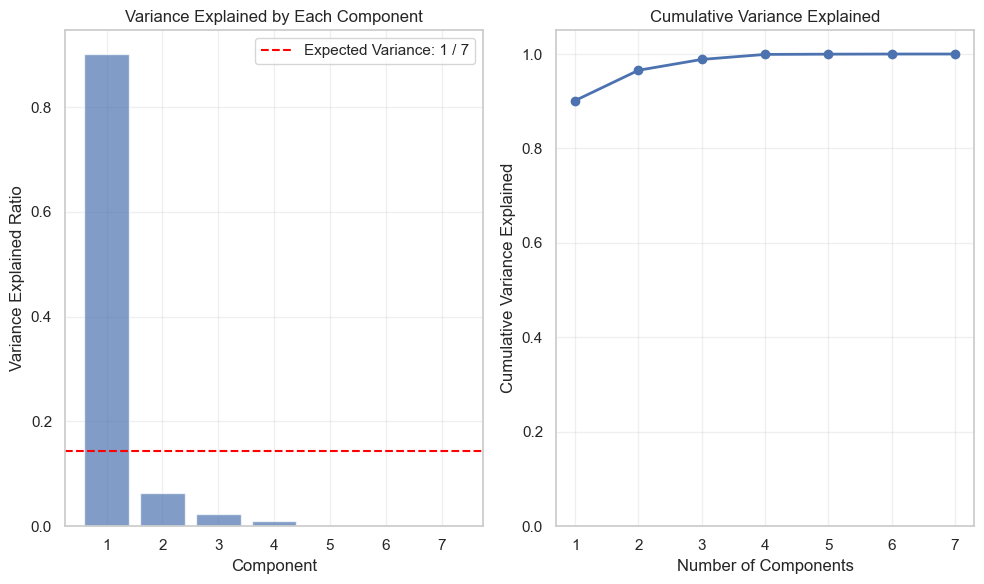

In [ ]:
# get the explained variance ratio and print it
fig = pca_model.plot_variance_explained()
plt.show()

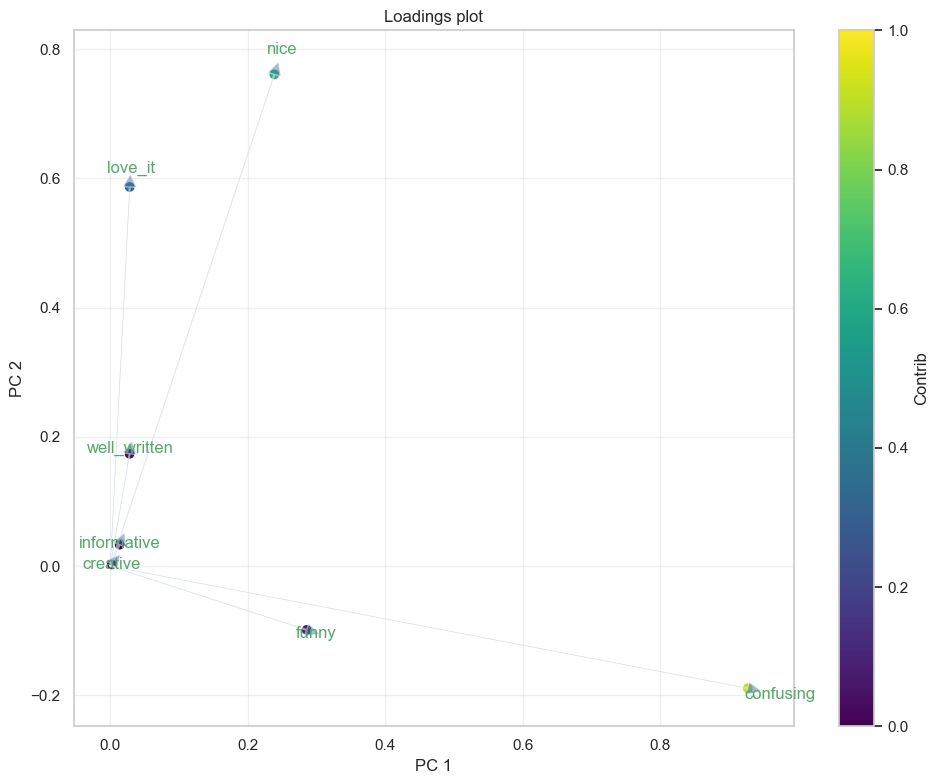

In [ ]:
fig = pca_model.plot_loadings_2d(draw_labels = True)
plt.show()

C:\Users\gonza\AppData\Local\Temp\ipykernel_9732\4082297775.py:19: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


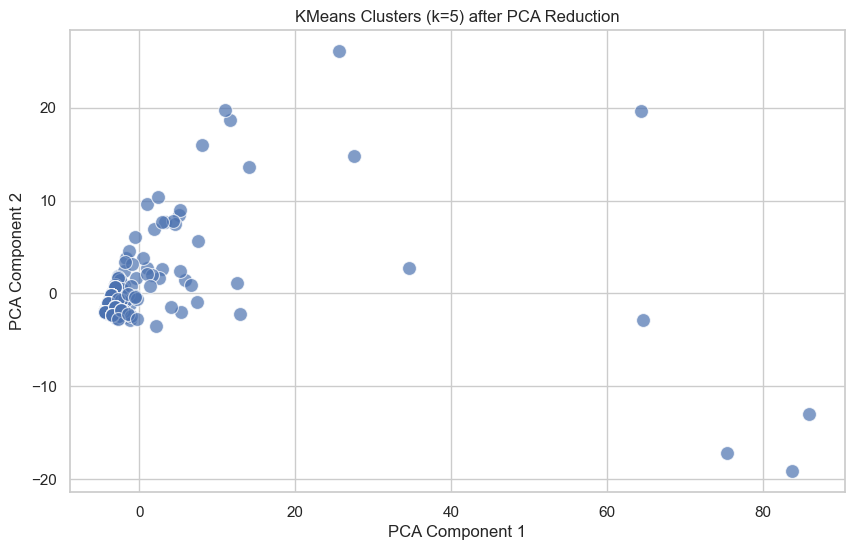

Explained variance ratio by PCA components: [8.33260270e-01 1.09853851e-01 2.68001728e-02 1.90422595e-02
 6.27751053e-03 4.63054365e-03 1.35393180e-04]


In [ ]:
anime_reaction_reviews_simple_2 = anime_reaction_reviews_simple.iloc[
    anime_reaction_reviews_pca[
    (
        (anime_reaction_reviews_pca["PC_0"] < 100)
         & (anime_reaction_reviews_pca["PC_1"] < 100)
    )
].index
]

pca_2 = PCA(n_components = 7)
anime_reaction_reviews_pca_2 = pca_2.fit_transform(anime_reaction_reviews_simple_2)
anime_reaction_reviews_pca_2 = pd.DataFrame(anime_reaction_reviews_pca_2)
anime_reaction_reviews_pca_2 = anime_reaction_reviews_pca_2.add_prefix('PC_')

k = 5
# labels = list(map(str,labels_list[k - 2]))
# anime_reaction_reviews_pca_2["labels"] = labels
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data = anime_reaction_reviews_pca_2,
    x = 'PC_0',
    y = 'PC_1',
    # hue = 'labels',
    palette = 'Set2',
    s = 100,
    alpha = 0.7
)

plt.title(f'KMeans Clusters (k={k}) after PCA Reduction')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

# get the explained variance ratio and print it
explained_variance = pca_2.explained_variance_ratio_
print("Explained variance ratio by PCA components:", explained_variance)

In [ ]:
anime_reaction_reviews_simple_2

,nice,love_it,funny,confusing,informative,well_written,creative
3,37,12,9,13,0,1,0
4,25,1,0,6,8,2,0
5,3,15,1,2,0,0,2
6,11,5,0,3,7,0,0
7,26,2,0,5,0,6,0
...,...,...,...,...,...,...,...
218,10,0,0,15,0,1,0
220,18,14,19,77,2,5,1
221,49,0,10,53,2,0,0
222,28,2,25,83,3,4,0
